# HadCRUT5 Surface Temperature Anomalies

Surface temperature anomalies from the Met Office Hadley Centre and the Climatic Research Unit,
published on a global grid and averaged here onto countries. An anomaly is a deviation from
HadCRUT's own reference period rather than an absolute temperature, which is what makes values
comparable between a tropical country and an Arctic one.

## Provenance

| Field | Value |
|---|---|
| Publisher | Met Office Hadley Centre, with the Climatic Research Unit, University of East Anglia |
| Source | <https://crudata.uea.ac.uk/cru/data/temperature/HadCRUT.5.0.2.0.analysis.anomalies.ensemble_mean.nc> |
| License | Open Government License v3 |
| Citation | HadCRUT.5.0.2.0 analysis anomalies, ensemble mean, obtained from <https://www.metoffice.gov.uk/hadobs/hadcrut5> and (c) British Crown Copyright, Met Office, provided under an Open Government License. |
| Cache file | `HadCRUT.5.0.2.0.analysis.anomalies.ensemble_mean.nc` as downloaded, `hadcrut__repaired_iso=True.parquet` once processed |
| Declaration checked | 2026-08-05 |

These are the fields of the `HADCRUT` declaration in `climate_risk/data/hadcrut.py`, which is what
`fetch` reads. Check that file rather than this page if the two ever disagree.

## Loading it

The published file is a NetCDF grid. The loader joins every grid point to the country whose boundary
contains it and averages within each country and year, so a cold run pulls the world shapefile into
the cache as well. The cache directory is your choice, and this page uses one named `data` in the
working directory.

In [1]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import climate_risk as cr

from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [2]:
cache_dir = Path("data")

anomalies = cr.load_hadcrut_data(cache_dir)

## What you get

A pandas frame, not polars, indexed by country and year. Which of the two a loader returns varies
across this package, so it is worth checking per loader.

In [3]:
anomalies.head()

surface_temperature_dev
ISO year                               
AFG 1960-01-01                    -0.18
    1961-01-01                    -0.04
    1962-01-01                    -0.32
    1963-01-01                     0.73
    1964-01-01                    -0.92

## Coverage

`describe` answers the spread of the one column. The span and the country count live in the index,
so they are read off it separately.

In [4]:
anomalies.describe()

,surface_temperature_dev
count,6732.00
mean,0.45
std,0.69
min,-2.23
25%,-0.02
50%,0.36
75%,0.86
max,4.55


In [5]:
years = anomalies.index.get_level_values("year")

pd.DataFrame(
    {
        "countries": [anomalies.index.get_level_values("ISO").nunique()],
        "first year": [years.min().year],
        "last year": [years.max().year],
    }
)

,countries,first year,last year
0,102,1960,2025


## A plot

Norway against Argentina, the fastest and among the slowest warming countries in the record. Both
are anomalies against the same baseline, so the gap between them is the point: warming is not
distributed evenly, and a per-country series is the only way to see that.

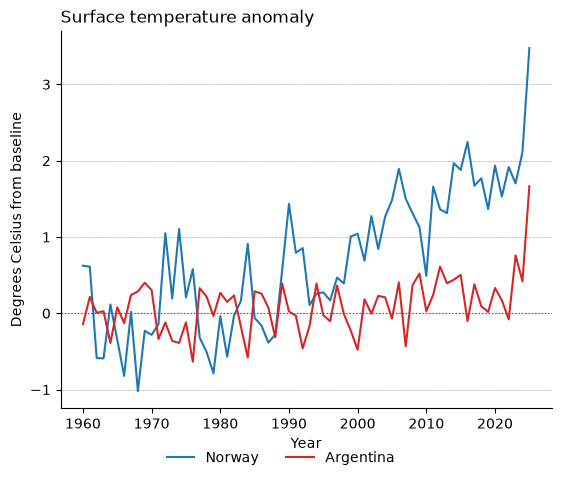

In [6]:
FEATURED = {"NOR": "Norway", "ARG": "Argentina"}
SERIES_COLORS = (PALETTE["primary"], PALETTE["secondary"])

figure, axis = plt.subplots(figsize=(5.5, 4.5))

for (iso, name), color in zip(FEATURED.items(), SERIES_COLORS, strict=True):
    country = anomalies.xs(iso, level="ISO")
    axis.plot(country.index, country["surface_temperature_dev"], color=color, label=name)

axis.axhline(0.0, color=PALETTE["divider"], ls=":", lw=0.9)
axis.set_title("Surface temperature anomaly", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Degrees Celsius from baseline")

handles, labels = axis.get_legend_handles_labels()
figure.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(labels),
    frameon=False,
)

plt.show()

## Gotchas

*The last year is a partial average, and seasonally biased.* The loader averages whatever months the
gridded file holds for a year. The cached file ends in February, so 2025 is a January and February
mean rather than an annual one, which is why both series jump at the right edge. Check the time
range of the NetCDF before reading anything into the most recent year.

*It returns pandas, and the index does the work.* The frame is indexed by `ISO` and `year`, with one
`surface_temperature_dev` column. Reach a country with `.xs("NOR", level="ISO")` rather than a
boolean mask on a column that is not there.

*`year` is a timestamp, not an integer.* Each year is stamped at its first day, so it joins onto the
other annual series. Comparing it to `1990` raises rather than filtering.

*Around a hundred countries survive, not two hundred.* A country's value is the mean of the grid
points whose centers fall inside its boundary, so a country smaller than the grid spacing collects
none and drops out entirely. Absence here is a resolution artifact, not missing weather.

*The record starts in 1960, and the constant says 1959.* `FIRST_PANEL_YEAR` is 1959 and the filter
keeps years strictly greater than it. The gridded file reaches back to 1850, and the early decades
are too sparse to average onto countries.

*Loading it builds the world boundaries too.* The join needs `load_shapefile("world", ...)`, so a
cold run fetches and unpacks that archive before this frame appears.

*`repair_ISO_codes` is part of the cache key.* It defaults to True and corrects the boundary file's
ISO codes before the join. Calling with False builds a second cache entry rather than replacing the
first.